1a. Encontrar los puntos singulares para los siguientes sistemas. Linealizar las ecuaciones del sistema en su entorno y determinar la naturaleza de dichos puntos singulares.
$$
\begin{aligned}
\dot x_1 &= x_2 \\
\dot x_2 &= -x_1 + x_2(1 -x_2^2) 
\end{aligned}
$$

En primer lugar, importamos las librerías necesarias para resolver nuestro problema. En este caso necesitamos scipy para los integradores numéricos (ode45, el famoso par de Dormund and Prince, es el que usa por defecto). numpy, para trabajar con matrices y operaciones matemáticas, matplolib para los dibujillos y sympy para resolver ecuaciones simbolicas. Dejo solo las importaciones en la celda siguiente para que el código quede limpito.


In [35]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [36]:
#Creamos las variables simbólicas
x1, x2, s = sp.symbols('x1 x2 s')

Definimos el sistema. Para ello creamos directamente una matriz (Vector simbólico) En que cada fila contiene una de las ecuaciones simbólicas de estado.

In [37]:
f = sp.Matrix([x2, -x1 + x2*(1 - x2**2)])
print(f)

Matrix([[x2], [-x1 + x2*(1 - x2**2)]])


Calculamos el Jacobiano del sistema, En Scipy es directamente un método del objeto Matrix

In [38]:
J = f.jacobian([x1, x2])
print(J)

Matrix([[0, 1], [-1, 1 - 3*x2**2]])


Calculamos los puntos de equilibrio, igualando a cero las ecuaciones del sistema y resolviendolo. Para ello basta emplear el comando solver de scipy

In [39]:
sol = sp.solve(f, [x1, x2])
print(sol)

[(0, 0)]


En este caso, solo tenemos un punto de equilibrio. Pero en cualquier caso, vamos a usar un bucle para recorrer los puntos de equilibrio encontrados y calcular 'en cada uno' la versión linealizada del sistema.

In [40]:
for sl in sol:
    #sustituimos los valores de x1 y x2 en el Jacobiano
    J_sym = J.subs({x1: sl[0], x2: sl[1]})
    #obtener el Jacobiano numérico 
    J_num = np.array(J_sym.evalf(),dtype=float)
    #obtenemos los valores propios del Jacobiano
    #podemos hacerlo de manera simbólica o numérica
    #pero el simbólico tarda mucho más tiempo en calcularlo
    eigenvaluessym = J_sym.eigenvals()
    #los pasamos a numericos. Hay que tener en cuenta que 
    # los valores propios simbólicos son un diccionario, donde las claves 
    #son los valores propios y los valores son su multiplicidad,
    # por lo que hay que convertirlo a una lista.
    #además, los valores propios simbólicos pueden ser complejos, 
    # por lo que hay que convertirlos a números complejos.
    #ojo sympy emplea I mayúscula para representar la unidad imaginaria. 8()
    eigenvalues_sym2num = list(eigenvaluessym.keys())
    #convertimos los valores propios simbólicos a números complejos
    eigenvalues_sym2num = [complex(val) for val in eigenvalues_sym2num]
    #obtenemos los valores propios del Jacobiano de manera numérica
    eigenvalues = np.linalg.eigvals(J_num)
    #Construimos el polinomio característico del Jacobiano
    #Es una alternativa a la obtención de los valores propios.
    D = (s*sp.eye(2) - J_sym).det()
    print('punto de equilibrio:', sl)
    print('Jacobiano simbólico:', J_sym)
    print('Jacobiano num:', J_num)
    print('Valores propios simbólicos:', eigenvaluessym)
    print('Valores propios simbólicos (numéricos):', eigenvalues_sym2num)
    print('Valores propios numéricos:', eigenvalues)
    print('Polinomio característico:', D)


punto de equilibrio: (0, 0)
Jacobiano simbólico: Matrix([[0, 1], [-1, 1]])
Jacobiano num: [[ 0.  1.]
 [-1.  1.]]
Valores propios simbólicos: {1/2 - sqrt(3)*I/2: 1, 1/2 + sqrt(3)*I/2: 1}
Valores propios simbólicos (numéricos): [(0.5-0.8660254037844386j), (0.5+0.8660254037844386j)]
Valores propios numéricos: [0.5+0.8660254j 0.5-0.8660254j]
Polinomio característico: s**2 - s + 1


Nuestros autovalores son complejos conjugados, con parte real positiva, por tanto, el punot de equilibrio es inestable, Las soluciones que empiecen suficientemente cerca de él se alejarán describiendo una espiral.

Por último vamos a representar el plano de fases del sistema. Lo primero que hacemos es crear una función que represente las ecuaciones de la dinámica de nuestro sistema,

In [41]:
#el tiempo siempre debe ser el primer argumento de la función aunque el sistema sea autónomo.
#para que el integrador de scipy funcione correctamente. La función debe devolver un array 
# o lista con las derivadas de cada variable.
def ej1a(t,x):
    x1, x2 = x
    dx1dt = x2
    dx2dt = -x1 + x2*(1 - x2**2)
    return [dx1dt, dx2dt]

Construimos ahora los elementos necesarios para dibujar el plano de fases

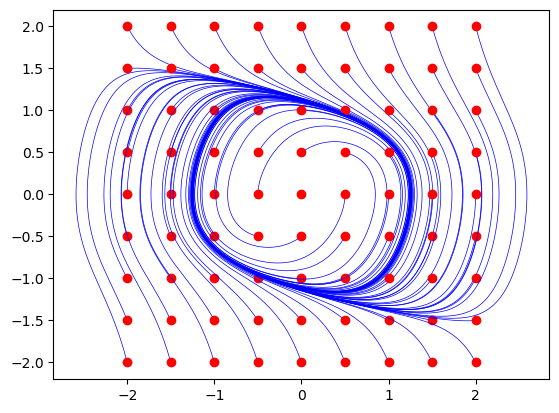

In [42]:
fig, ax = plt.subplots()
#condiciones iniciales
c_ini = np.arange(-2, 2.001, 0.5) 
for i in c_ini:
    for j in c_ini:
        #resolvemos el sistema de ecuaciones diferenciales
        #[0, 10] es el intervalo de tiempo en el que se resuelve el sistema
        #fijamos un paso máximo de integración de 0.01 para que la solución sea más precisa
        sol = solve_ivp(ej1a, [0, 10], [i, j],max_step=0.01)
        ax.plot(sol.y[0], sol.y[1], 'b',linewidth=0.5) #trayectoria
        ax.plot(i, j, 'ro') #punto inicial